# Supervised Learning

## 1. Necessary Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (confusion_matrix, 
                             precision_score, 
                             recall_score,
                             f1_score, 
                             accuracy_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2. Preliminary Setup

In [101]:
# Visualization!
sns.set_theme(style = "whitegrid", context = "notebook")

# Decimals!
pd.set_option("display.float_format", "{:.3f}".format)

# Plot sizes!
FIG = (18, 16)
FS = 14

## 3. Dataset Load

In [102]:
all = pd.read_csv("../data/clean/combo_clean_all.csv")

## 4. Univariate Linear Models

Let $l:\mathbb{R}\to\mathbb{R}$ by

$$
\hat{y}_i=l\left(x_i\mid\vec{\theta}\right)=\theta_0+\theta_1x_i \tag*{(1)}
$$

be a proposed *univariate linear model* for $X=\{x_1,\,x_2,\,\ldots,\,x_n\}$ and $Y=\{y_1,\,y_2,\,\ldots,\,y_n\}$.

Then, the *error* or *loss function* can be defined as the *mean squared error (MSE)*

$$
\ell(y_i,\,\hat{y}_i)=\frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2 \tag*{(2)}
$$

$$
=\frac{1}{n}\sum_{i=1}^n(y_i-(\theta_0+\theta_1x_i))^2=\frac{1}{n}\sum_{i=1}^n(y_i-\theta_0-\theta_1x_i)^2=\ell\left(\vec{\theta}\mid\vec{z}_i\right)
$$

in this case, where 

$$
\varepsilon_i=y_i-\hat{y}_i \tag*{(3)}
$$

are the *residuals*, $\vec{z}_i=(x_i,\,y_i)$, and $\hat{y}_i$ are the *predictions* on the given data.

Of course, there exist *closed-form solutions* for the *slope* and *intercept* here via *minimization* of the loss function:

$$
\theta_0=\bar{y}-\theta_1\bar{x} \tag*{(4)}
$$

where $\bar{x}$ and $\bar{y}$ are the *averages* of $X$ and $Y$, respectively, and

$$
\theta_1=\frac{\sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^n(x_i-\bar{x})^2}=\frac{\mathrm{Cov}(X,\,Y)}{\mathrm{Var}(X)} \tag*{(5)}
$$

It's also important to note that the *parameter vector* $\vec{\theta}\in\mathbb{R}^{k+1}$ where $k$ is the *dimension* of the *feature space*. In univariate linear regression, $k=1$, of course, so $\vec{\theta}\in\mathbb{R}^2$.

### A. Expected wOBA vs. SLG

Based on results from the EDA, I will construct an initial linear model where expected wOBA is the *independent variable* and SLG is the *dependent variable*. This trend is not pictured in the EDA (the final section).

Again, wOBA assigns *different weights* to 1B, 2B, 3B, HR, BB (and IBB), and HBP to approximate their true run value. It is essentially a more accurate version of OPS. Here is the current formula: 

$$
\text{wOBA}=\frac{w_{\text{BB}}\cdot(\text{BB}-\text{IBB})+w_{\text{HBP}}\cdot\text{HBP}+w_{\text{1B}}\cdot\text{1B}+w_{\text{2B}}\cdot\text{2B}+w_{\text{3B}}\cdot\text{3B}+w_{\text{HR}}\cdot\text{HR}}{\text{AB}+\text{BB}-\text{IBB}+\text{SF}+\text{HBP}} \tag*{(6)}
$$

It turns out that the weight values change each year given changing run environments. For example, if in a given year HR decrease, then they therefore *become rarer and more valuable, so the HR weight will increase for the following year*.

Regardless, expected wOBA is a Statcast metric that estimates a players wOBA by evaluating the quality of their contact rather than the actual outcome. For each batted ball, *Statcast's ML model (not open-source but likely a k-NN-style density estimator) assigns probabilities to different results based on how similar its LA and EV are to historical batted balls*. In some cases, player attributes such as sprint speed are also incorporated. For instance, faster runners receive higher probabilities of reaching base on ground balls.

The model takes as *inputs* the following:

- EV
- LA
- Spray angle
- Batted-ball type (ground ball, line drive, fly ball, etc.)
- Sometimes runner speed for plays where speed influences the outcome

And it learns to predict the *probability of each outcome*:

- 1B
- 2B
- 3B
- HR
- Out

The *weighted sum* of those outcome probabilities yields the expected wOBA.

It is important to recognize here the limits of the following analysis. Both expected wOBA and SLG ultimately *encode similar underlying events* (hard contact and extra-base hits), so the strong linear relationship is not particularly surprising or analytically deep. The following linear regression task is more insightful, and I compare/contrast the two below.

[@Wikipedia-wOBA]

In [103]:
# Select relevant columns!
reg_df_1 = all[["expected_weighted_on_base_average", "slg"]].dropna().copy()

# Define x and y!
x_1 = reg_df_1[["expected_weighted_on_base_average"]]
y_1 = reg_df_1["slg"]

# Fit linear regression model!
linreg_1 = LinearRegression()
linreg_1.fit(x_1, y_1)

# Predictions and model fit!
y_pred_1 = linreg_1.predict(x_1)
r_2_1 = r2_score(y_1, y_pred_1)

# Display results!
print(f"Intercept: {linreg_1.intercept_:.3f}\n")
print(f"Slope: {linreg_1.coef_[0] * 0.010:.3f}\n")
print(f"R-squared: {r_2_1:.3f}")

Intercept: -0.083

Slope: 0.016

R-squared: 0.623


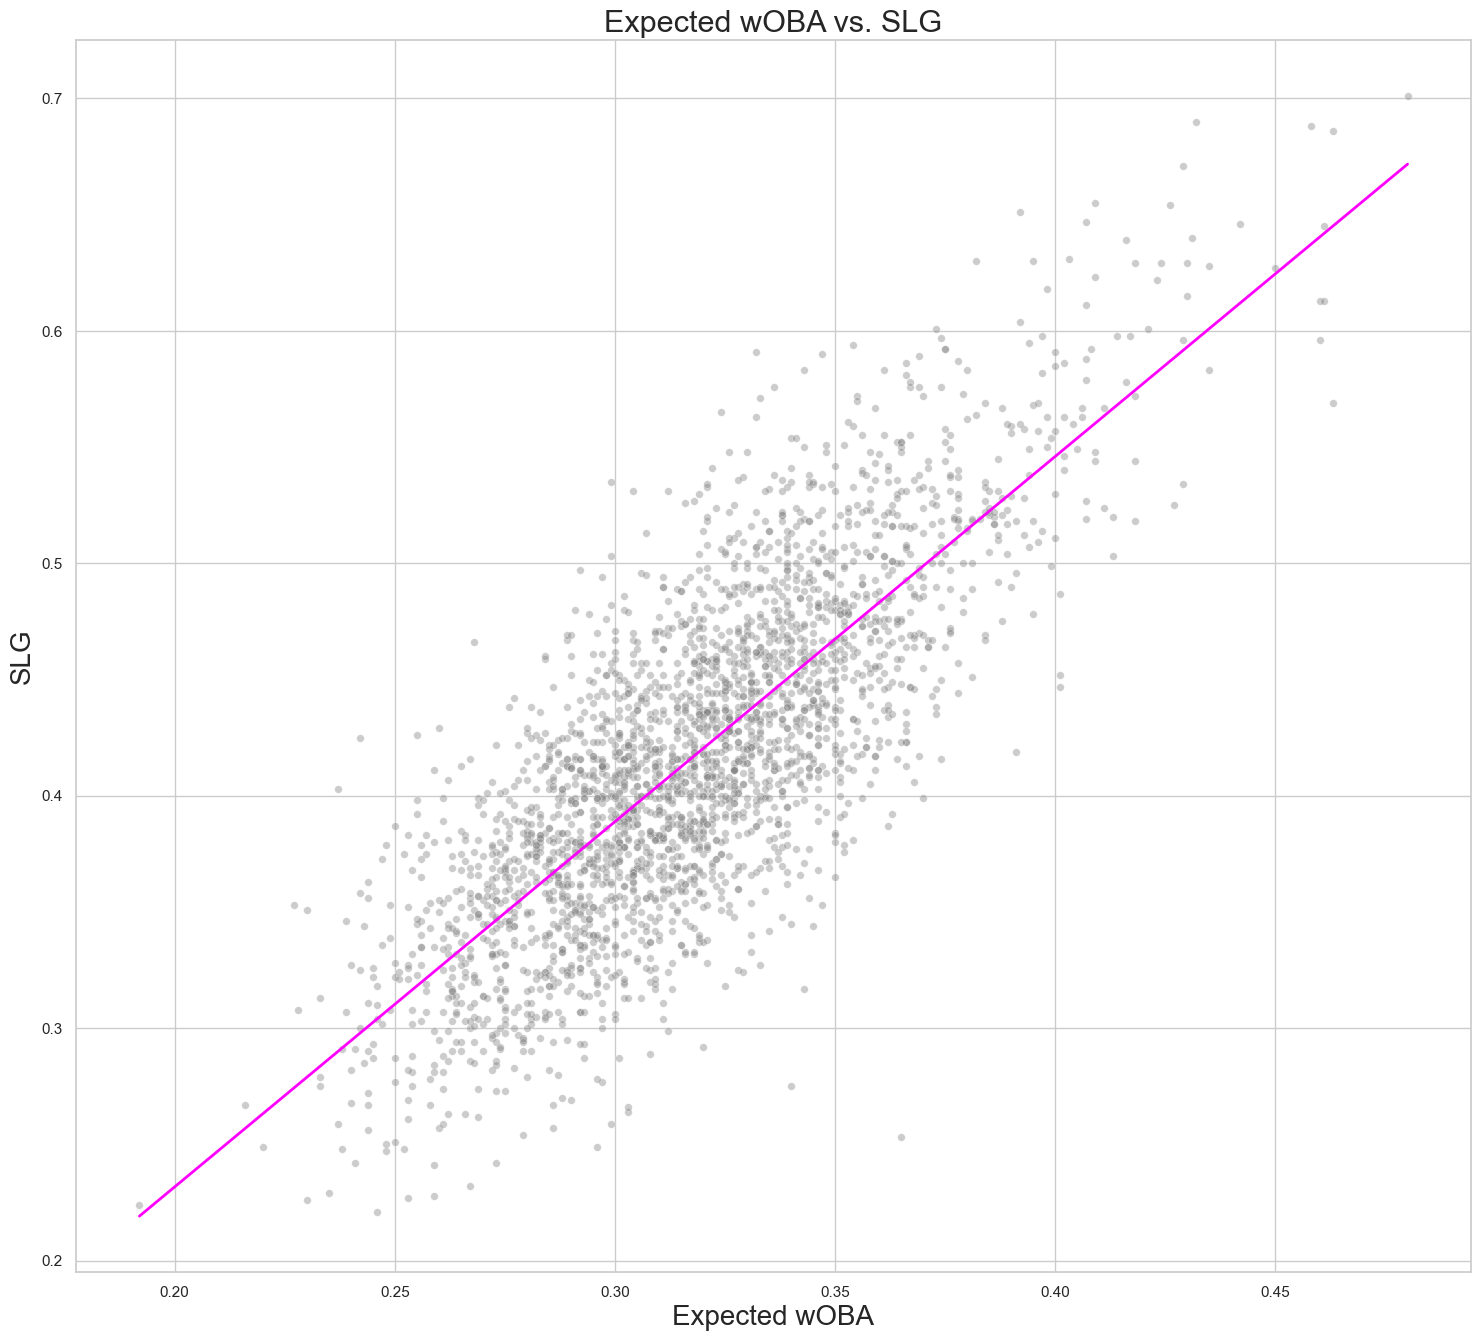

In [104]:
# Set size!
plt.figure(figsize = FIG)

# Scatter of all players!
sns.scatterplot(data = reg_df_1,
                x = "expected_weighted_on_base_average",
                y = "slg",
                color = "gray",
                alpha = 0.4,
                s = 30)

# Regression line!
x_vals_1 = np.linspace(reg_df_1["expected_weighted_on_base_average"].min(),
                       reg_df_1["expected_weighted_on_base_average"].max(),
                       200)
x_vals_df_1 = pd.DataFrame({"expected_weighted_on_base_average": x_vals_1})
y_vals_1 = linreg_1.predict(x_vals_df_1)

# Plot!
plt.plot(x_vals_1, y_vals_1, color = "magenta", linewidth = 2)
plt.title("Expected wOBA vs. SLG", fontsize = FS + 8)
plt.xlabel("Expected wOBA", fontsize = FS + 6)
plt.ylabel("SLG", fontsize = FS + 6)
plt.show()

Note:

-  The *coefficient of determination* $(R^2)$ is, in the case of simple linear *regression* with a single independent variable, the square of the *Pearson correlation coefficient* between $X$ and $Y$, so here, since $R^2=0.623$, $\rho_{X,\,Y}=\sqrt{0.623}=0.789$. 

- $R^2$ represents the proportion of the *variance* in the dependent variable $(Y)$ that can be explained by the independent variable $(X)$. Here, $R^2=0.623$ indicates that approximately $62.3\%$ of the variance in SLG can be explained by expected wOBA, suggesting, as predicted, a strong linear association between underlying contact quality (as measured by Statcast) and realized power production.

- At the same time, the remaining $37.7\%$ of the variance reflects factors not captured by expected wOBA. These include ballpark dimensions, defensive positioning, baserunning speed, pitcher quality, randomness in batted-ball outcomes, and situational context. Because SLG is a realized, outcome-based metric, it is naturally *noisier* than expected wOBA, which averages over many batted-ball events.

### B. Barrel Percentage vs. ISO

As stated in `Data_Cleaning.ipynb`, a "barrel" is a batted ball with the *optimal combination* of EV and LA (e.g., $98+$ mph at $26-30$ degrees), so barrel percentage (the independent variable here) is simply calculated via the following:

$$
\text{Barrel Percentage}=\frac{\text{Barrels}}{\text{Batted Balls}} \tag*{(7)}
$$

ISO, which is the dependent variable here, again, highlights extra-base power by simply *subtracting* AVG from SLG:

$$
\text{ISO}=\text{SLG}-\text{AVG} \tag*{(8)}
$$

In [105]:
# Select relevant columns!
reg_df_2 = all[["barrel_percentage", "iso"]].dropna().copy()

# Define x and y!
x_2 = reg_df_2[["barrel_percentage"]]
y_2 = reg_df_2["iso"]

# Fit linear regression model!
linreg_2 = LinearRegression()
linreg_2.fit(x_2, y_2)

# Predictions and model fit!
y_pred_2 = linreg_2.predict(x_2)
r_2_2 = r2_score(y_2, y_pred_2)

# Display results!
print(f"Intercept: {linreg_2.intercept_:.3f}\n")
print(f"Slope: {linreg_2.coef_[0] * 0.010:.3f}\n")
print(f"R-squared: {r_2_2:.3f}")

Intercept: 0.084

Slope: 0.011

R-squared: 0.627


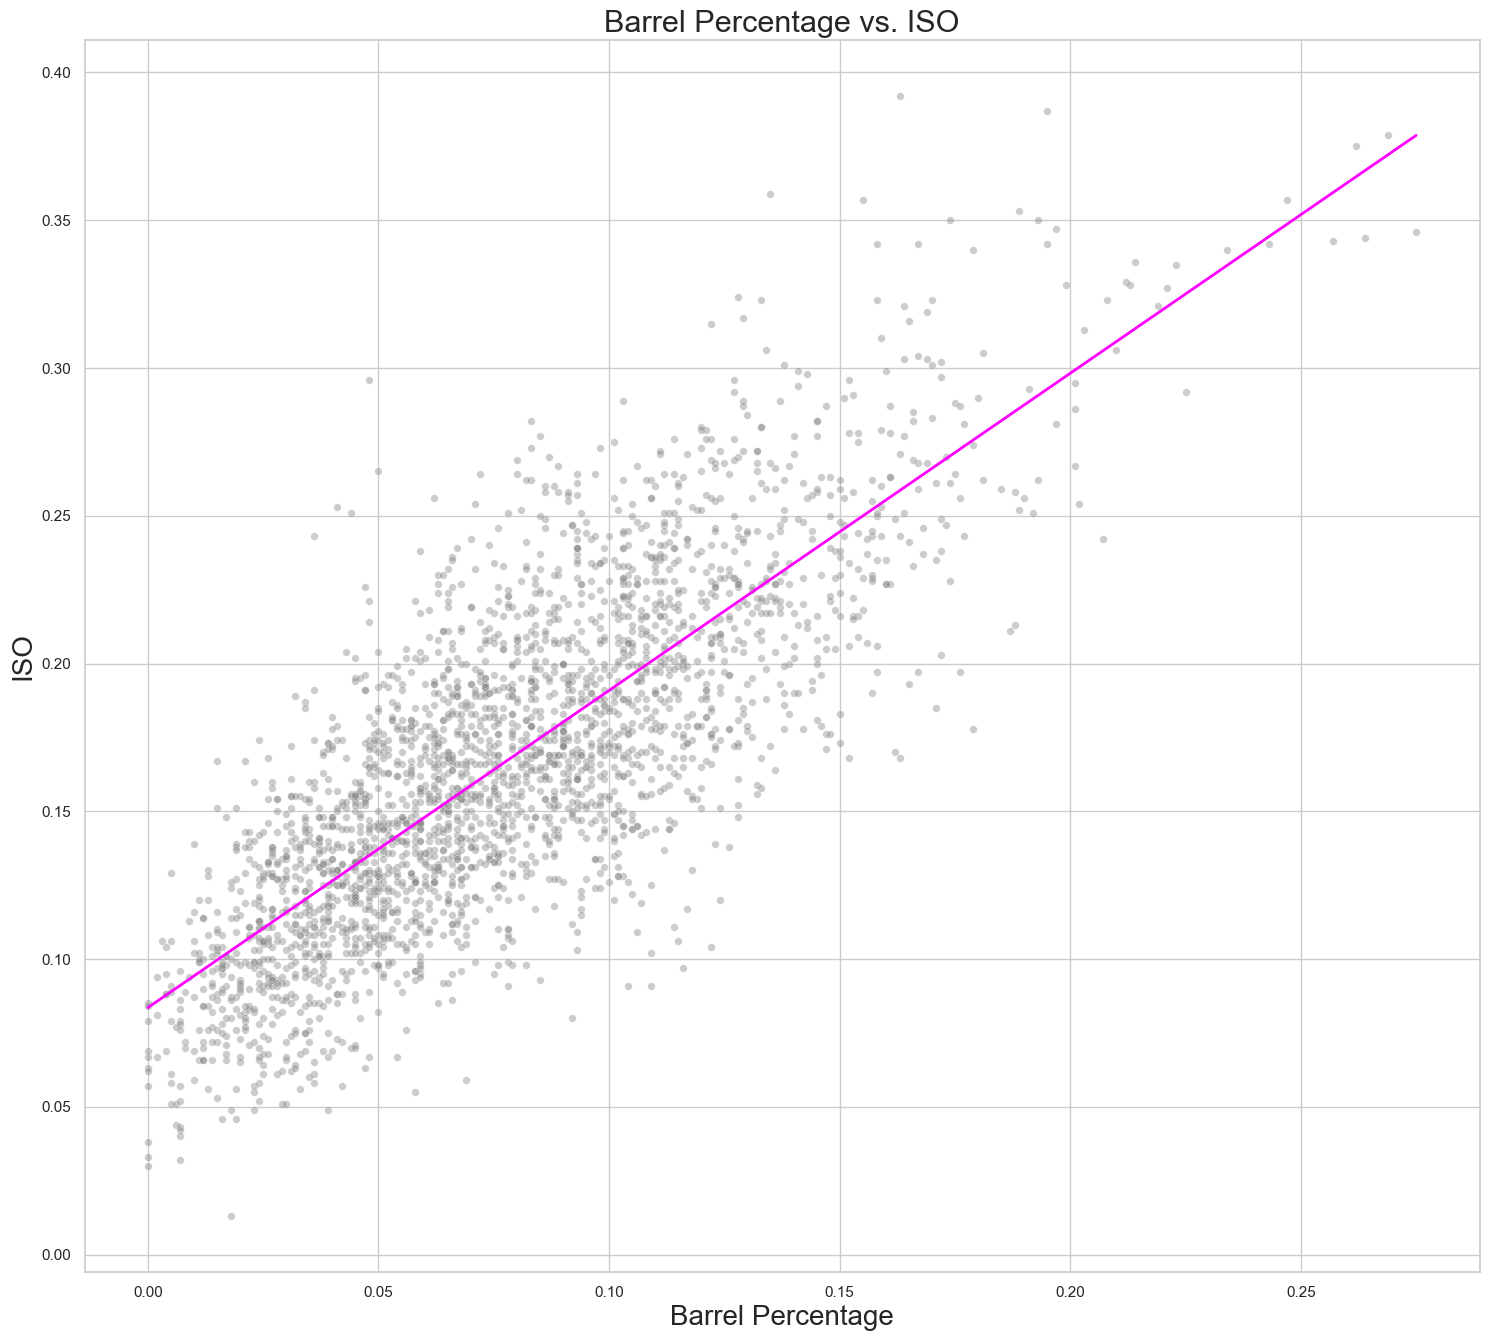

In [106]:
# Set size!
plt.figure(figsize = FIG)

# Scatter of all players!
sns.scatterplot(data = reg_df_2,
                x = "barrel_percentage",
                y = "iso",
                color = "gray",
                alpha = 0.4,
                s = 30)

# Regression line!
x_vals_2 = np.linspace(reg_df_2["barrel_percentage"].min(),
                       reg_df_2["barrel_percentage"].max(),
                       200)
x_vals_df_2 = pd.DataFrame({"barrel_percentage": x_vals_2})
y_vals_2 = linreg_2.predict(x_vals_df_2)

# Plot!
plt.plot(x_vals_2, y_vals_2, color = "magenta", linewidth = 2)
plt.title("Barrel Percentage vs. ISO", fontsize = FS + 8)
plt.xlabel("Barrel Percentage", fontsize = FS + 6)
plt.ylabel("ISO", fontsize = FS + 6)
plt.show()

Note: 

- The regression of barrel percentage and ISO yields an $R^2$ of $0.627$, slightly higher than the $R^2=0.623$ observed in the expected wOBA–SLG linear model. Since $R^2=0.627$, the corresponding correlation is $\rho_{X,\,Y}=\sqrt{0.627}=0.792$. Although expected wOBA and SLG *share more overlapping components of offensive performance*, this does not guarantee a tighter linear relationship. Both are broad, composite statistics affected by many sources of noise (ballpark variation, defensive positioning, randomness on balls in play, BB percentages, and context-specific outcomes), so their relationship is strong but not maximally aligned.

- By contrast, barrel percentage and ISO form a more conceptually direct pairing because barrel percentage captures the quality of contact through the rate of optimally struck balls, while ISO identifies the outcome of that contact by measuring extra-base power independent of AVG. *Because their definitions are more narrowly focused and mechanically linked, there is less extraneous noise between them*, leading to a slightly higher $R^2$. This makes the barrel percentage vs. ISO relationship more interpretable from a baseball perspective: the strong correlation indicates that barrels reliably predict true power production, while deviations from the trend highlight hitters who overperform or underperform relative to their underlying contact quality.

## 5. Multivariate/Logistic/Binary Classifier

Let $\sigma:\mathbb{R}^k\to\mathbb{R}$ by

$$
\hat{y}=\sigma(\vec{x}\mid\vec{w})=\sigma(z)=\frac{1}{1+e^{-z}} \tag*{(9)}
$$

where

$$
z=w_0+w_1x_1+w_2x_2+\cdots+w_kx_k \tag*{(10)}
$$

be a *sigmoid activation function* for a *multivariate logistic classifier* that predicts two *classes*: *positive* $(y=1)$ and *negative* $(y=0)$.

Hence, this is a *binary* classifier where the parameter vector $\vec{w}\in\mathbb{R}^{k+1}$ given a $k$-dimensional feature space.

The error function here is defined as the *binary cross-entropy (BCE)* by

$$
\beta(y,\,\hat{y})=-\left(y\ln(\hat{y})+(1-y)\ln(1-\hat{y})\right) \tag*{(11)}
$$

Hence, if $y=1$, then

$$
\beta(1,\,\hat{y})=-\ln(\hat{y})=-\ln\left(\frac{1}{1+e^{-z}}\right)=-(\ln(1)-\ln(1+e^{-z}))=\ln(1+e^{-z})=\beta(z),
$$

so

$$
\frac{d\beta}{dz}=\frac{-e^{-z}}{1+e^{-z}}=-\frac{e^{-z}}{1+e^{-z}}=-\sigma(-z)=-(1-\sigma(z))=\sigma(z)-1=\hat{y}-1
$$

Therefore, by the *chain rule*,

$$
\frac{d\beta}{dw_0}=\frac{d\beta}{dz}\frac{dz}{dw_0}=\hat{y}-1,\quad\frac{d\beta}{dw_1}=\frac{d\beta}{dz}\frac{dz}{dw_1}=(\hat{y}-1)x_1,\quad\frac{d\beta}{dw_2}=\frac{d\beta}{dz}\frac{dz}{dw_2}=(\hat{y}-1)x_2,\quad\ldots,\quad\frac{d\beta}{dw_k}=\frac{d\beta}{dz}\frac{dz}{dw_k}=(\hat{y}-1)x_k
$$

If $y=0$, then

$$
\beta(0,\,\hat{y})=-\ln(1-\hat{y})=-\ln(1-\sigma(z))=-\ln(\sigma(-z))=-\ln\left(\frac{1}{1+e^z}\right)=\ln(1+e^z)=\beta(z),
$$

so

$$
\frac{d\beta}{dz}=\frac{e^z}{1+e^z}=\sigma(z)=\hat{y}
$$

Therefore,

$$
\frac{d\beta}{dw_0}=\hat{y},\quad\frac{d\beta}{dw_1}=\hat{y}x_1,\quad\frac{d\beta}{dw_2}=\hat{y}x_2,\quad\ldots,\quad\frac{d\beta}{dw_k}=\hat{y}x_k
$$

Thus, the (combined) *gradient* $\nabla\beta:\mathbb{R}^{k+1}\to\mathbb{R}^{k+1}$ is defined as

$$
\nabla\beta(\vec{w})=(\hat{y}-y)\vec{x^*} \tag*{(12)}
$$

where $\vec{x^*}=(1,\,x_1,\,x_2,\,\ldots,\,x_k)$.

Thus, the (total) gradient for a dataset with $n$ *observations* is defined as

$$
\nabla\beta(\vec{w})=\sum_{i=1}^n(\hat{y}_i-y_i)\vec{x_i^*}=\sum_{i=1}^n\left(\sigma(\vec{x}_i\mid\vec{w})-y_i\right)\vec{x^*}_i \tag*{(13)}
$$

Finally, it follows that that *gradient descent update* here looks like the following (as, unlike linear regression, there is no closed-form solution for the parameter vector, so gradient descent is necessary):

$$
\vec{w}_{j+1}=\vec{w}_j-\varsigma\,\nabla\beta(\vec{w}_j) \tag*{(14)}
$$

$$
=\vec{w}_j-\varsigma\,\sum_{i=1}^n\left(\sigma(\vec{x}_i\mid\vec{w}_j)-y_i\right)\vec{x^*}_i \tag*{(15)}
$$

where $\varsigma\in\mathbb{R}$ is the *step size* (a *hyperparameter*) and $j$ is the *iteration* of the parameter vector.

### A. Target Creation

"Elite" season counts:

elite_season
0    2368
1     427
Name: count, dtype: int64 

"Elite" season proportions:

elite_season
0   0.847
1   0.153
Name: proportion, dtype: float64 



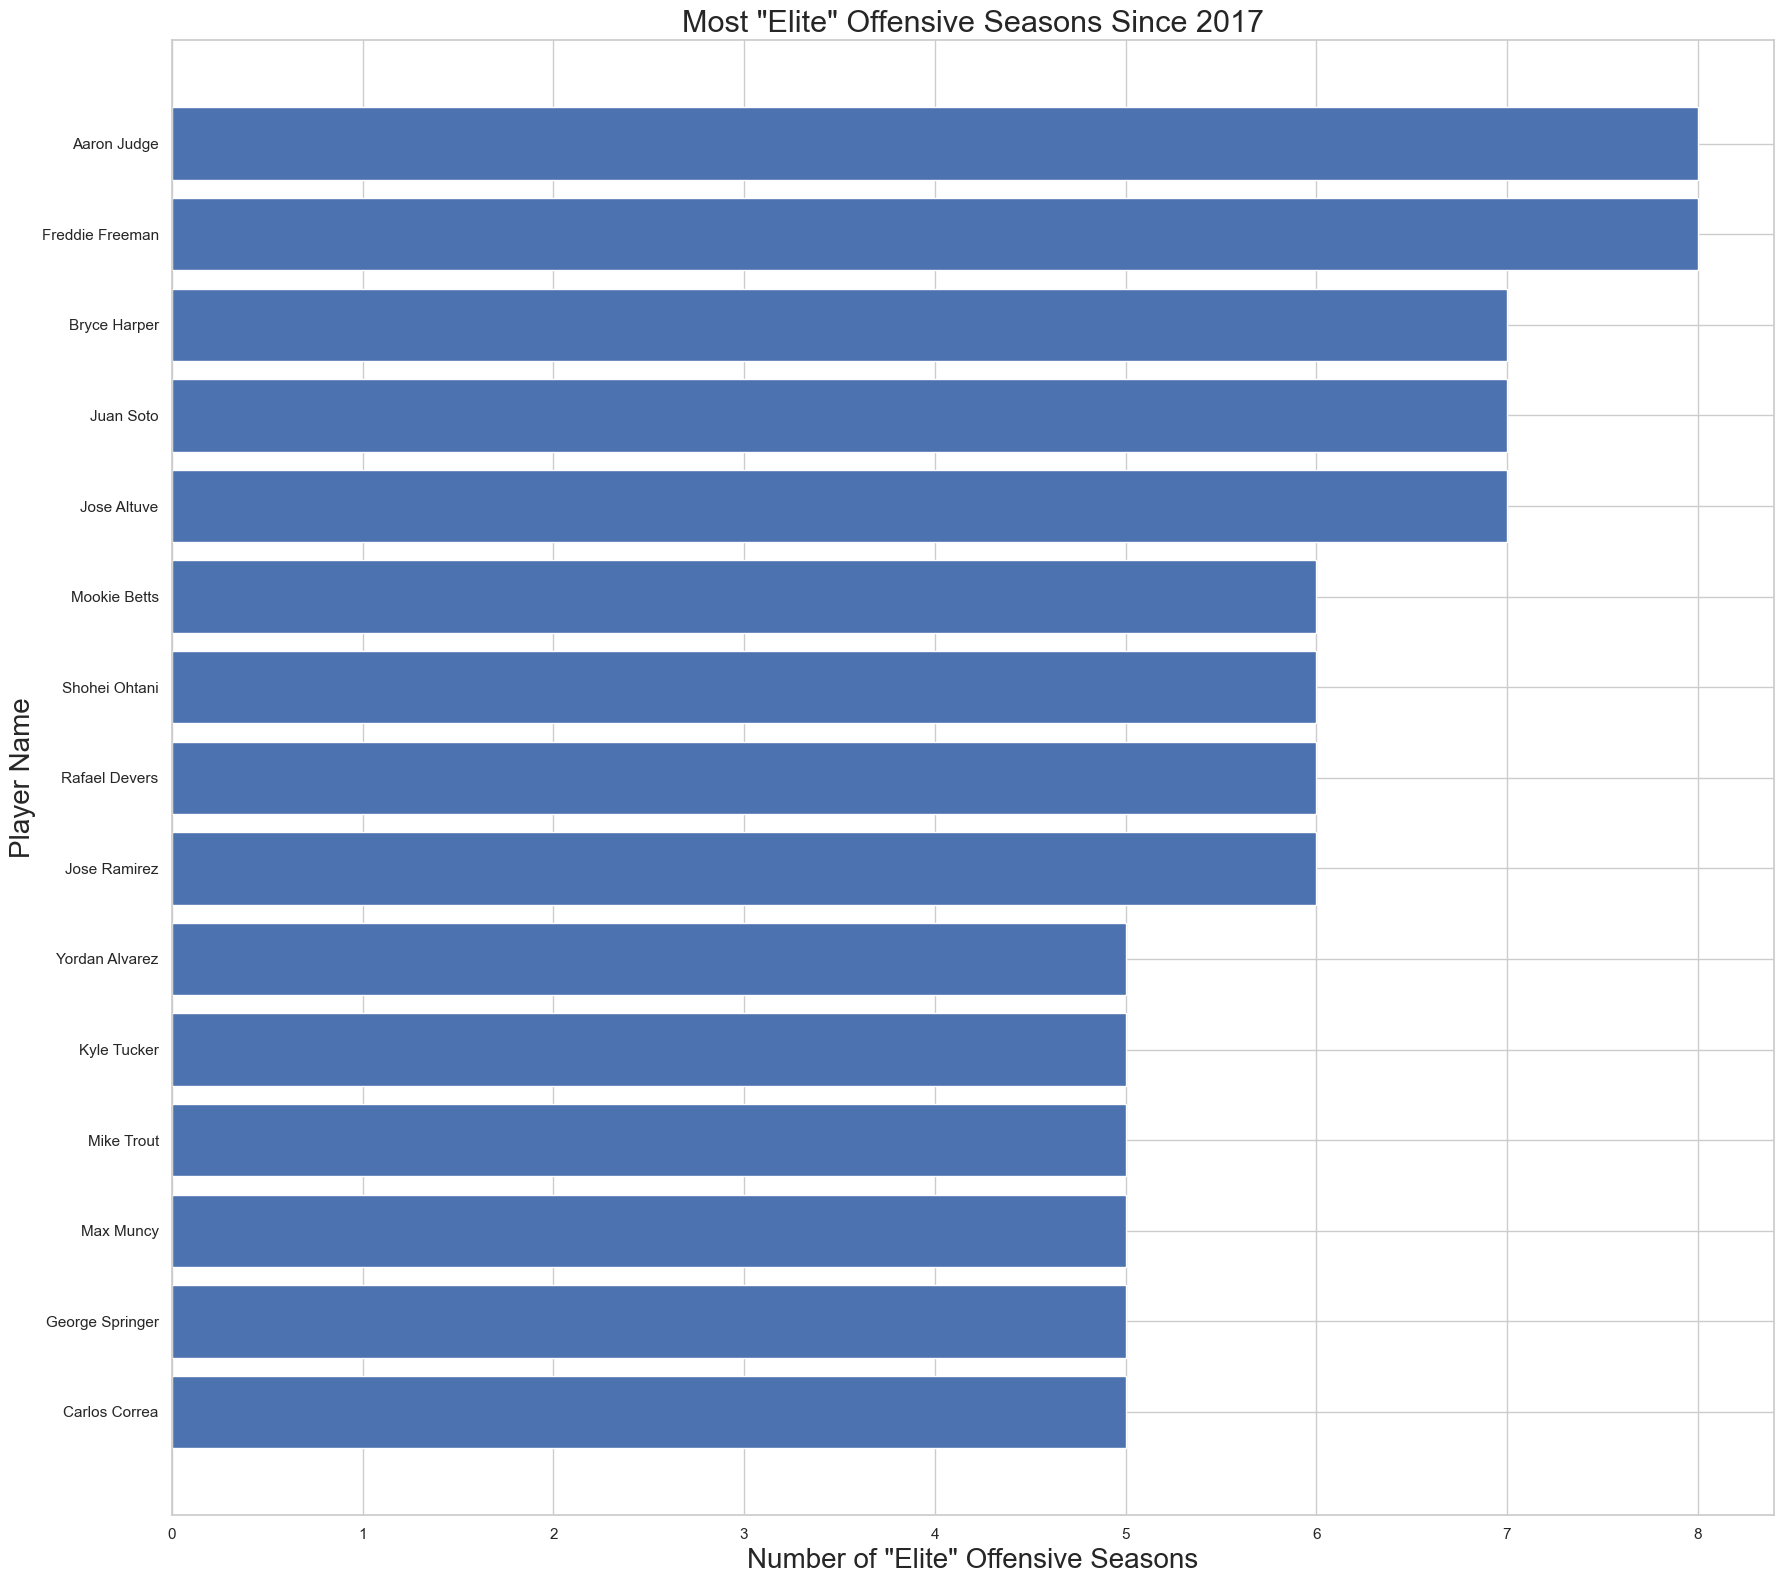

In [107]:
# Make a working copy!
elite_df = all.copy()

# Compute season-specific "elite" thresholds!
elite_thresholds = (elite_df.groupby("season")["weighted_runs_created_plus"].quantile(0.85))

# Create season-level "elite" indicator!
elite_df["elite_season"] = (elite_df["weighted_runs_created_plus"] >= elite_df["season"].map(elite_thresholds)).astype(int)

# Inspect balance!
elite_counts = elite_df["elite_season"].value_counts().sort_index()
elite_proportions = elite_df["elite_season"].value_counts(normalize = True).sort_index()

# Results!
print(""""Elite" season counts:\n""")
print(elite_counts, "\n")
print(""""Elite" season proportions:\n""")
print(elite_proportions, "\n")

# Count "elite" seasons per player for plotting!
elite_counts = (elite_df.groupby(["first_name", "last_name"])["elite_season"].sum().reset_index().rename(columns = {"elite_season": "elite_seasons"}).sort_values("elite_seasons", ascending = False))

# Keep top players only for plotting!
TOP_N = 15
top_elite = elite_counts.head(TOP_N).copy()

# Create player name column for plotting!
top_elite["player"] = top_elite["first_name"] + " " + top_elite["last_name"]

# Plot!
plt.figure(figsize = FIG)
plt.barh(top_elite["player"], top_elite["elite_seasons"])
plt.title("""Most "Elite" Offensive Seasons Since 2017""", fontsize = FS + 8)
plt.xlabel("""Number of "Elite" Offensive Seasons""", fontsize = FS + 6)
plt.ylabel("Player Name", fontsize = FS + 6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Note: 

- To frame this supervised learning task, I am defining a player's season as *"elite"* if they ranked in the top $15\%$ of wRC+. Applying this threshold yields a class distribution of, as seen above, $15.3\%$ elite seasons and $84.7\%$ non-elite seasons from 2017-2025, closely reflecting the natural scarcity of truly exceptional offensive production in the MLB. As seen in the plot, Aaron Judge and Freddie Freeman are tied with the most $(8)$ elite seasons since 2017. Therefore, they've both had elite seasons every year for the past nine years, excluding 2020, which is remarkable. With this ground truth established, the goal of the logistic regression model that follows is to use some underlying contact quality and plate discipline characteristics to classify hitter's seasons as elite or not.

- Again, wRC+ improves wOBA by *adjusting for ballpark and run environment* –

    - $100 =$ league average

    - $150 = 50\%$ better than league average

    - $200 = 100\%$ better than league average

### B. Initial Feature Selection And Standardization/Normalization

To *standardize* a variable $X=\{x_1,\,x_2,\,\ldots,\,x_n\}$, one does the following:

$$
z_i=\frac{x_i-\bar{x}}{\sigma_X} \text{ ($z$-score)} \tag*{(16)}
$$

for $1\leq i<n$.

After this, the *mean* is equal to $0$ and the *standard deviation, variance* are equal to $1$.

In [108]:
# Select process-oriented features only!
feature_cols = [
    
    # Contact quality!
    "avg_exit_velocity",
    "max_exit_velocity",
    "barrel_percentage",
    "sweet_spot_percentage",
    "hard_hit_percentage",
    "avg_launch_angle",
    "exit_velocity_95_mph_plus_count",
    "avg_distance_hit",
    "max_distance_hit",
    "hard_hit_balls",
    "barrels",
    "medium_hit_percentage",
    "soft_hit_percentage",
    
    # Plate discipline!
    "bb_percentage",
    "so_percentage",
    "walks_to_strikeouts_ratio",
    "outside_swing_percentage",
    "zone_swing_percentage",
    "swinging_strike_percentage",
    "called_strike_whiff_percentage",
    "called_strike_percentage",
    "foul_strike_percentage",
    "zone_percentage",
    "contact_percentage",
    "zone_contact_percentage",
    "outside_contact_percentage",
    "swing_percentage"
               ]

# Build modeling `DataFrame`!
model_df = elite_df[feature_cols + ["elite_season"]].dropna().copy()

# Separate X and y!
X = model_df[feature_cols]
y = model_df["elite_season"]

# Impute and standardize predictors!
imputer = SimpleImputer(strategy = "median")
X_imp = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# Convert back to `DataFrame` for interpretability!
X_scaled = pd.DataFrame(X_scaled, columns = feature_cols, index = X.index)

# Sanity checks!
print("Number of observations used:", X_scaled.shape[0], "\n")
print("Number of features:", X_scaled.shape[1], "\n")
print("Feature means after scaling:\n")
print(X_scaled.mean().round(3), "\n\n")
print("Feature standard deviations after scaling:\n")
print(X_scaled.std().round(3))

Number of observations used: 1968 

Number of features: 27 

Feature means after scaling:

avg_exit_velocity                  0.000
max_exit_velocity                 -0.000
barrel_percentage                 -0.000
sweet_spot_percentage             -0.000
hard_hit_percentage               -0.000
avg_launch_angle                  -0.000
exit_velocity_95_mph_plus_count    0.000
avg_distance_hit                  -0.000
max_distance_hit                   0.000
hard_hit_balls                    -0.000
barrels                           -0.000
medium_hit_percentage             -0.000
soft_hit_percentage                0.000
bb_percentage                      0.000
so_percentage                      0.000
walks_to_strikeouts_ratio         -0.000
outside_swing_percentage          -0.000
zone_swing_percentage              0.000
swinging_strike_percentage        -0.000
called_strike_whiff_percentage    -0.000
called_strike_percentage          -0.000
foul_strike_percentage            -0.000
zone_pe

Note: The initial modeling dataset, as seen above, contains $1968$ observations and $27$ predictors. *All predictors have been standardized to an mean of zero and unit variance (and hence standard deviation)* in a new `DataFrame` called `X_scaled`, ensuring numerical stability during optimization and allowing the resulting logistic regression coefficients to be interpreted on a common scale.

### C. Removing Redundant And Multicollinear Features

In [109]:
# Parameters!
CORR_THRESH = 0.85
VIF_THRESH = 5

# Correlation-based pruning!
corr = X_scaled.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESH)]
X_work = X_scaled.drop(columns = to_drop_corr)
print("Dropped by correlation threshold:\n")
print(to_drop_corr, "\n")

# Domain-informed pruning!
domain_drop = ["barrels",
               "hard_hit_balls",
               "exit_velocity_95_mph_plus_count",
               "max_exit_velocity",
               "max_distance_hit"]
domain_drop = [c for c in domain_drop if c in X_work.columns]
X_work = X_work.drop(columns = domain_drop)
print("Dropped by domain knowledge:\n")
print(domain_drop, "\n")

# VIF elimination!
def compute_vif(df):
    return pd.DataFrame({"feature": df.columns,
                         "VIF": [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]}).sort_values("VIF", ascending = False)
print("Dropped by VIF:\n")
while True:
    vif_df = compute_vif(X_work)
    max_vif = vif_df["VIF"].iloc[0]
    if max_vif <= VIF_THRESH:
        break
    drop_feat = vif_df["feature"].iloc[0]
    print(f"'{drop_feat}'")
    X_work = X_work.drop(columns = drop_feat)

# Final output!
X_final = X_work.copy()
print("\nFinal feature set:\n")
print(X_final.columns.tolist(), "\n")
print("Final number of features:", X_final.shape[1], "\n")
print("Final VIF table:\n")
print(compute_vif(X_final))

Dropped by correlation threshold:

['hard_hit_percentage', 'hard_hit_balls', 'barrels', 'called_strike_percentage', 'contact_percentage', 'zone_contact_percentage', 'outside_contact_percentage', 'swing_percentage'] 

Dropped by domain knowledge:

['exit_velocity_95_mph_plus_count', 'max_exit_velocity', 'max_distance_hit'] 

Dropped by VIF:

'swinging_strike_percentage'
'so_percentage'
'avg_distance_hit'
'bb_percentage'

Final feature set:

['avg_exit_velocity', 'barrel_percentage', 'sweet_spot_percentage', 'avg_launch_angle', 'medium_hit_percentage', 'soft_hit_percentage', 'walks_to_strikeouts_ratio', 'outside_swing_percentage', 'zone_swing_percentage', 'called_strike_whiff_percentage', 'foul_strike_percentage', 'zone_percentage'] 

Final number of features: 12 

Final VIF table:

                           feature   VIF
0                avg_exit_velocity 4.571
1                barrel_percentage 4.421
7         outside_swing_percentage 3.446
6        walks_to_strikeouts_ratio 3.413
9  

Note: 

- The feature-pruning procedure is designed to remove redundancy and *multicollinearity* in a principled, staged way, so that the final logistic regression model remains both statistically stable and interpretable. The first step uses pairwise correlation pruning: because all predictors are standardized, absolute Pearson correlations are directly comparable. *Any feature that exhibits a correlation above 0.85 with at least one other predictor is removed*, ensuring that near-duplicate measurements of the same underlying skill (for example, multiple highly-related contact or swing metrics) do not enter the model simultaneously. This step eliminates obvious linear redundancy and substantially reduces the risk of unstable coefficient estimates.

- The second step applies domain-informed pruning, which reflects substantive knowledge about baseball performance metrics. When multiple variables encode essentially the same information, *preference is given to percentage-based and typical-performance measures over raw counts or extrema*. This further improves interpretability and cross-player comparability while reducing sensitivity to playing time and outliers. Finally, the remaining predictors are subjected to *variance inflation factor (VIF)* elimination, which captures multicollinearity arising from higher-order relationships not visible in pairwise correlations alone. Features with VIFs exceeding $5$ are iteratively removed until all remaining predictors fall below this threshold. The result is a parsimonious set of $12$ features, each representing a distinct aspect of contact quality or plate discipline, with all VIFs in an acceptable range. This ensures that estimated coefficients are stable, meaningful, and suitable for substantive interpretation rather than being artifacts of collinearity.

### D. Regularization, Fitting, Hyperparameter Tuning, Cross-Validation, And Evaluation

To *regularize* a model, one adds a *penalty* to the loss function to discourage large parameters. Here, *L2 (or ridge)* regularization is utilized without penalizing the *bias* term $w_0$:

$$
\text{L2}=\varrho\,\sum_{p=1}^kw_p^2 \tag*{(17)}
$$

$\varrho\in\mathbb{R}$ is the *regularization parameter* (a hyperparameter) that controls the strength of the penalty. Larger values of $\varrho$ enforce stronger shrinkage of the coefficients toward zero, while smaller values place greater emphasis on fitting the training data. Excluding the bias/intercept term from the penalty ensures that regularization constrains only the influence of the input features rather than shifting the baseline prediction.

In the context of this project, L2 regularization is particularly well-suited because many offensive metrics, such as EV and barrel percentage, are strongly correlated. Ridge regularization stabilizes coefficient estimates by distributing weight across correlated predictors rather than allowing any single feature to dominate. This yields a more robust and interpretable model that reflects bundles of underlying hitting skills rather than overfitting to noise in individual statistics.

In terms of evaluating the model, the *precision* is the proportion of predicted positives that are correct:

$$
\text{Precision}=\frac{\text{TP}}{\text{TP}+\text{FP}} \tag*{(18)}
$$

Furthermore, the *recall* is the proportion of actual positives that are predicted correctly:

$$
\text{Recall}=\frac{\text{TP}}{\text{TP}+\text{FN}} \tag*{(19)}
$$

The *F1 score* is the harmonic mean of the precision and recall:

$$
\text{F1}=\frac{2\cdot\text{TP}}{2\cdot\text{TP}+\text{FP}+\text{FN}} \tag*{(20)}
$$

The *accuracy* is the proportion of all correct predictions:

$$
\text{Accuracy}=\frac{\text{TP}+\text{TN}}{\text{TP}+\text{TN}+\text{FP}+\text{FN}} \tag*{(21)}
$$

In [110]:
# Ensure alignment between X and y!
y_model = y.loc[X_final.index]

# Train-test split!
X_train, X_test, y_train, y_test = train_test_split(X_final, 
                                                    y_model, 
                                                    test_size = 0.30, 
                                                    stratify = y_model, 
                                                    random_state = 42)

# Base logistic regression model!
logit = LogisticRegression(penalty = "l2", 
                           class_weight = "balanced",
                           solver = "lbfgs",
                           max_iter = 1000,
                           random_state = 42)

# Regularization grid (log scale)!
param_grid = {"C": np.logspace(-3, 3, 13)}

# Stratified k-fold CV!
cv = StratifiedKFold(n_splits = 5,
                     shuffle = True,
                     random_state = 42)

# Grid search (optimize F1 score due to class imbalance)!
grid = GridSearchCV(estimator = logit,
                    param_grid = param_grid,
                    scoring = "f1",
                    cv = cv,
                    n_jobs = -1)

# Fit ONLY on training data!
grid.fit(X_train, y_train)

# Best model!
best_logit = grid.best_estimator_
print("Best regularization parameter:", round(grid.best_params_["C"], 3), "\n")
print("Best cross-validated F1 score:", round(grid.best_score_, 3), "\n")

# Test set predictions!
y_pred = best_logit.predict(X_test)
y_prob = best_logit.predict_proba(X_test)[:, 1]

# Confusion matrix!
cm = confusion_matrix(y_test, y_pred)

# Metrics!
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f_1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Results!
print("Confusion matrix:\n")
print(cm, "\n")
print(f"Precision: {precision:.3f}\n")
print(f"Recall: {recall:.3f}\n")
print(f"F1 score: {f_1:.3f}\n")
print(f"Accuracy: {accuracy:.3f}\n")

Best regularization parameter: 3.162 

Best cross-validated F1 score: 0.608 

Confusion matrix:

[[391  89]
 [ 22  89]] 

Precision: 0.500

Recall: 0.802

F1 score: 0.616

Accuracy: 0.812



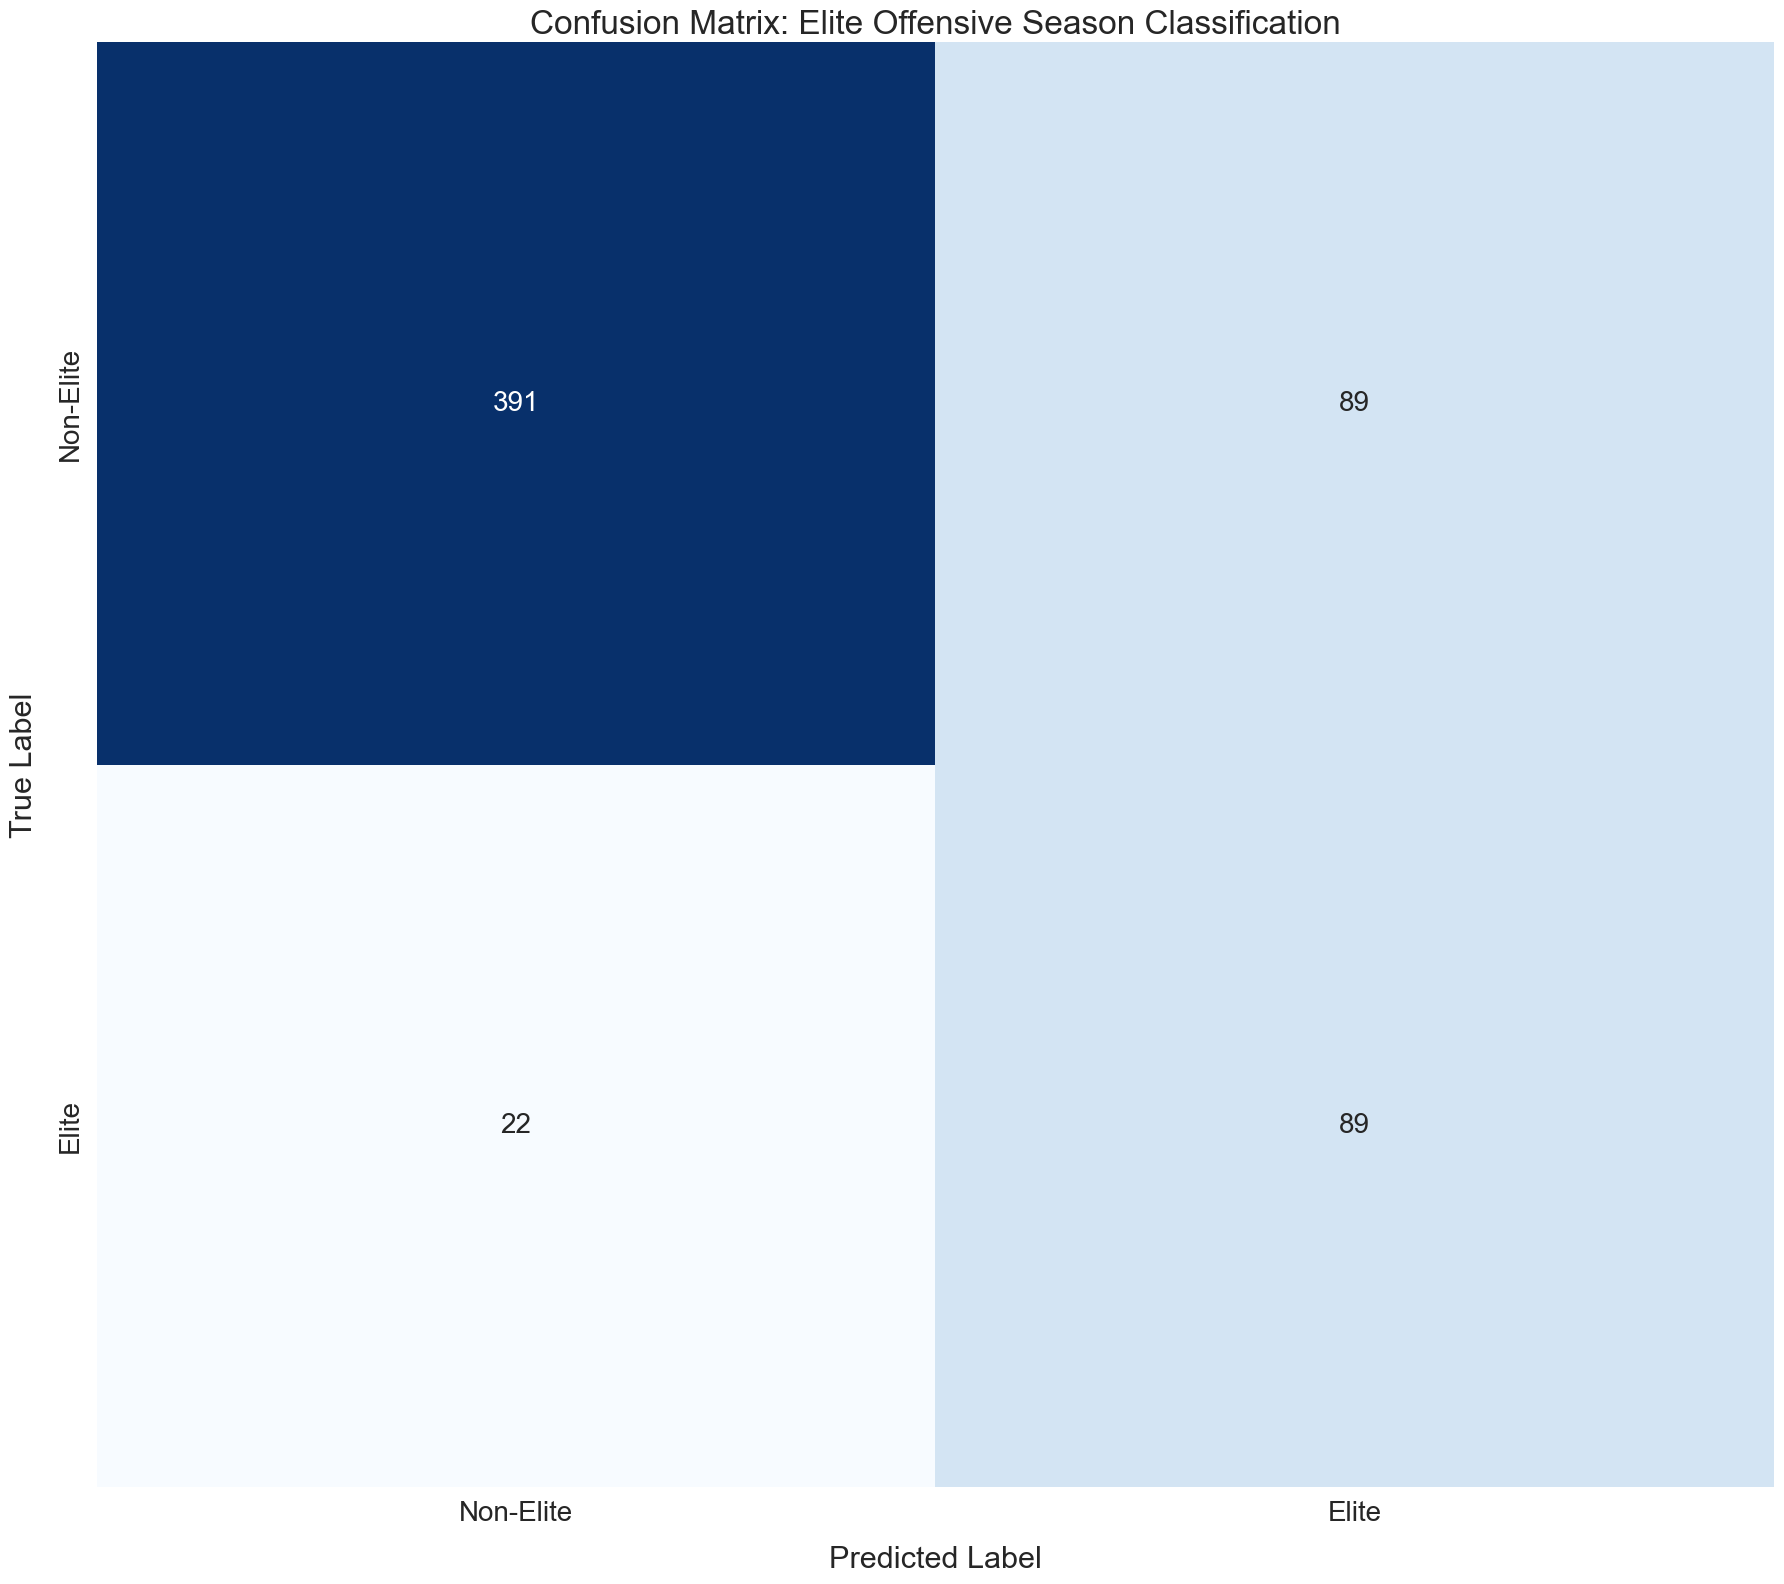

In [111]:
# Confusion matrix values!
cm = confusion_matrix(y_test, y_pred)

# Labels!
labels = ["Non-Elite", "Elite"]

# Plot!
plt.figure(figsize = FIG)
sns.heatmap(cm,
            annot = True,
            fmt = "d",
            cmap = "Blues",
            xticklabels = labels,
            yticklabels = labels,
            cbar = False,
            annot_kws = {"size": FS + 6})
plt.title("Confusion Matrix: Elite Offensive Season Classification", fontsize = FS + 10)
plt.xlabel("Predicted Label", fontsize = FS + 8, labelpad = FS)
plt.ylabel("True Label", fontsize = FS + 8, labelpad = FS)
plt.xticks(fontsize = FS + 6)
plt.yticks(fontsize = FS + 6)
plt.tight_layout()
plt.show()

Note: 

- Again, the probability that a player's season is classified as elite is modeled here using a regularized logistic regression framework. Predictors consist of standardized, process-oriented measures of contact quality and plate discipline, and multicollinearity is addressed through a sequential pruning procedure based on correlation thresholds, domain-informed exclusions, and variance inflation factor criteria. *Gradient descent is enforced using L-BFGS optimization algorithm, which adaptively determines step sizes* via an internal line search rather than relying on a fixed learning rate, ensuring stable convergence of the *convex*, penalized *objective function*.

- Again, coefficient shrinkage is imposed via an L2 penalty, with model complexity governed by the *inverse* regularization parameter $C$. Hyperparameter tuning is restricted to $C$, as it directly controls the *bias-variance tradeoff*, while all other model settings are fixed a priori. The optimal value of $C$ is selected using *stratified five-fold cross-validation* on the training data, with the F1 score used as the selection criterion to account for *class imbalance*. This procedure selects $C=3.162$, indicating moderate regularization and reflecting the increased stability afforded by the available sample size.

- The tuned model is evaluated on a held-out test set using precision, recall, F1 score, accuracy, and the confusion matrix. On the test data, the model achieves a recall of $0.802$, correctly identifying over $80\%$ of elite seasons, while maintaining a precision of $0.500$. The resulting F1 score of $0.616$ closely aligns with the cross-validated F1 score of $0.608$, indicating *consistent out-of-sample performance and limited sensitivity to the specific data split*. Although overall accuracy $(0.812)$ is high, emphasis is placed on recall and F1, as elite seasons constitute a *minority of observations and false negatives are substantively more costly than false positives*.